In [15]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [16]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [17]:
print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 1)
Testing Images : (10000, 32, 32, 3)
Testing Labels : (10000, 1)


In [18]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

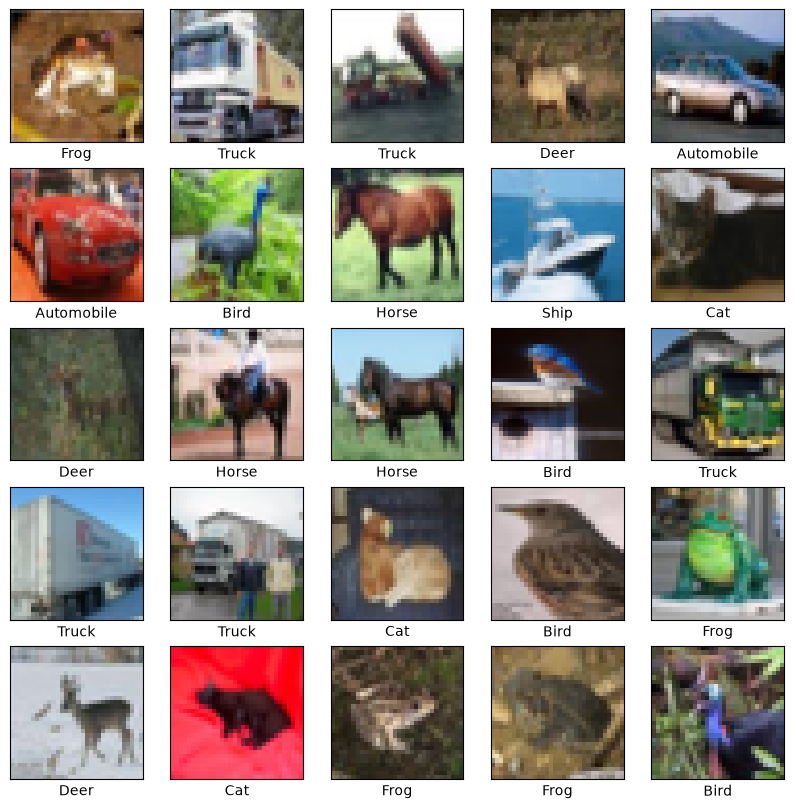

In [19]:
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.xlabel(class_names[y_train[i][0]])

plt.show()

In [20]:
X_train = X_train / 255.0
X_test = X_test / 255.0


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

model = Sequential([

    Input(shape=(32,32,3)),

    Conv2D(32,(3,3),padding='same',activation='relu'),
    BatchNormalization(),

    Conv2D(32,(3,3),padding='same',activation='relu'),
    BatchNormalization(),

    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(64,(3,3),padding='same',activation='relu'),
    BatchNormalization(),

    Conv2D(64,(3,3),padding='same',activation='relu'),
    BatchNormalization(),

    MaxPooling2D(),
    Dropout(0.30),

    Conv2D(128,(3,3),padding='same',activation='relu'),
    BatchNormalization(),

    Conv2D(128,(3,3),padding='same',activation='relu'),
    BatchNormalization(),

    MaxPooling2D(),
    Dropout(0.40),

    Flatten(),

    Dense(256,activation='relu'),
    Dropout(0.5),

    Dense(10,activation='softmax')
])

In [22]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.2
)

datagen.fit(X_train)

In [24]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [25]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 57ms/step - accuracy: 0.3309 - loss: 1.8486 - val_accuracy: 0.4693 - val_loss: 1.4436
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 54s 69ms/step - accuracy: 0.4665 - loss: 1.4786 - val_accuracy: 0.5108 - val_loss: 1.3973
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 106ms/step - accuracy: 0.5379 - loss: 1.3010 - val_accuracy: 0.5859 - val_loss: 1.1429
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 76s 97ms/step - accuracy: 0.5866 - loss: 1.1802 - val_accuracy: 0.6211 - val_loss: 1.1265
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 78s 100ms/step - accuracy: 0.6264 - loss: 1.0855 - val_accuracy: 0.6444 - val_loss: 1.0869
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 88ms/step - accuracy: 0.6505 - loss: 1.0163 - val_accuracy: 0.6309 - val_loss: 1.0740
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 80ms/step - accuracy: 0.6692 - loss: 0.9705 - val_accuracy: 0.7241 - val_loss: 0.8043
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 61s 78ms/step - accuracy: 0.6902 - loss: 0.9188 

In [26]:
 len(history.history['accuracy'])


44

In [27]:
print(max(history.history['val_accuracy']))

0.8622000217437744


In [28]:
model.save("models/cifar10_cnn_86.keras")

In [29]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8622 - loss: 0.4171
Test Accuracy: 0.8622
Test Loss: 0.4171


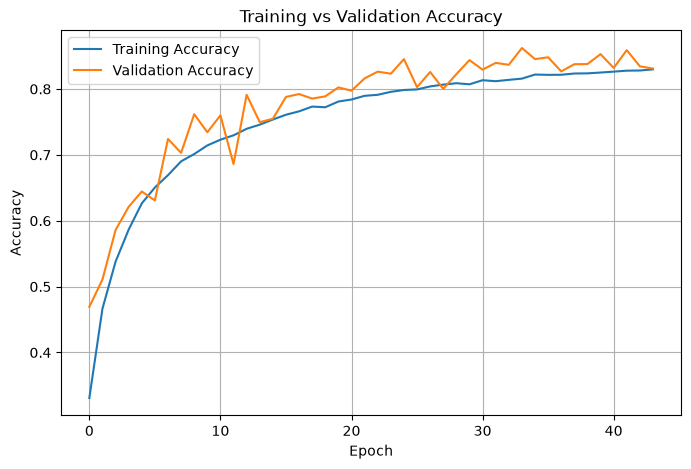

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

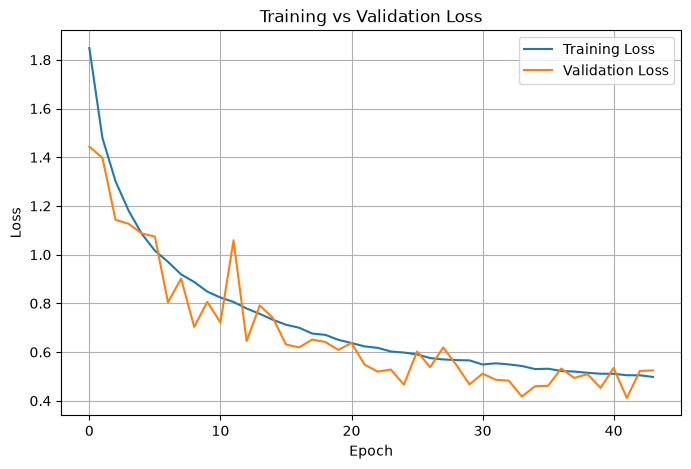

In [31]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [34]:
from sklearn.metrics import classification_report
import numpy as np

predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

print(classification_report(y_test, predicted_classes, target_names=class_names))


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
              precision    recall  f1-score   support

    Airplane       0.89      0.87      0.88      1000
  Automobile       0.91      0.97      0.94      1000
        Bird       0.86      0.80      0.83      1000
         Cat       0.82      0.65      0.72      1000
        Deer       0.85      0.86      0.86      1000
         Dog       0.85      0.75      0.80      1000
        Frog       0.77      0.95      0.86      1000
       Horse       0.87      0.92      0.89      1000
        Ship       0.90      0.94      0.92      1000
       Truck       0.89      0.92      0.91      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



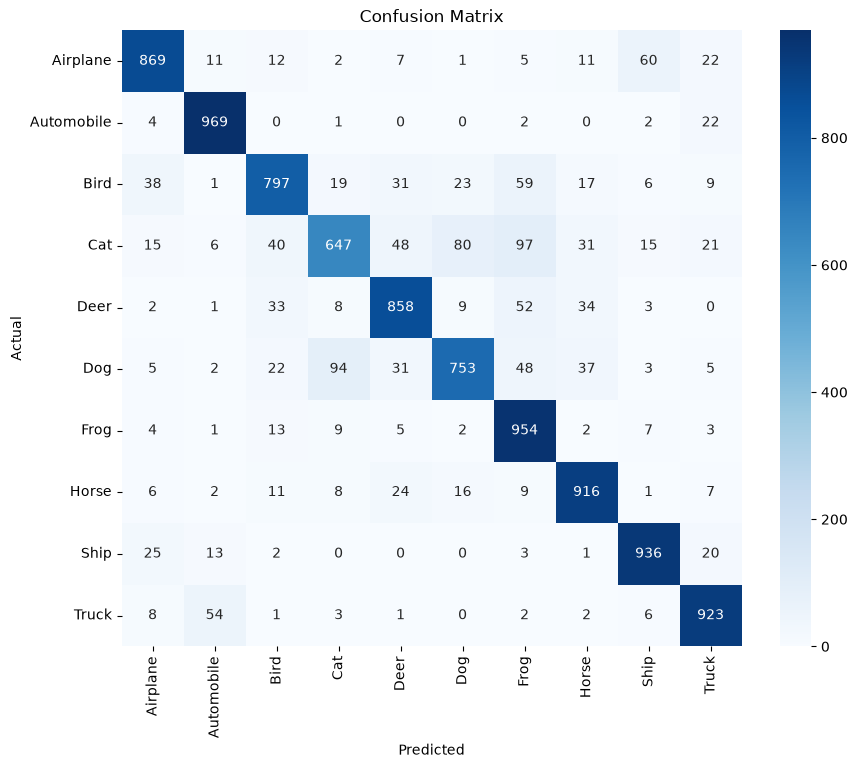

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()